## LIVESTOCK STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

livestock=pd.read_csv('../stock_data/livestock.csv') ## so it can be small letter. This is cool.
livestock=livestock.drop(columns=['high_price','low_price'])
livestock.rename(columns={'trade_date':'date'},inplace=True)
livestock['date']=pd.to_datetime(livestock['date'])
livestock['month']=livestock['date'].dt.month
livestock['quarter']=livestock['date'].dt.quarter
livestock['year']=livestock['date'].dt.year

livestock

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42783,LIVESTOCK,2017-01-03,0.84,0.84,1000,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43343,LIVESTOCK,2017-01-04,0.88,0.88,516800,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43453,LIVESTOCK,2017-01-05,0.88,0.88,100000,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43563,LIVESTOCK,2017-01-06,0.84,0.84,484563,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43653,LIVESTOCK,2017-01-09,0.84,0.84,143035,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298087,LIVESTOCK,2026-07-13,9.00,9.00,1940931,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298525,LIVESTOCK,2026-07-14,9.00,9.00,1255510,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298963,LIVESTOCK,2026-07-15,9.00,9.00,4388410,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299401,LIVESTOCK,2026-07-16,9.00,9.00,1161393,2026-07-16T15:10:03.113936+00:00,7,3,2026


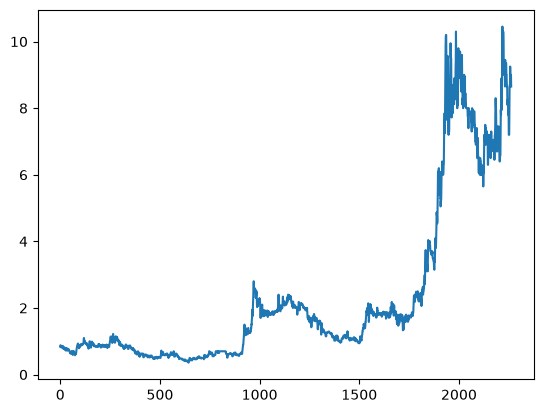

In [2]:
import matplotlib.pyplot as plt

plt.plot(livestock['close_price'])
plt.show()

In [3]:
livestock_end_month_df = (
    livestock
    .sort_values("date")
    .groupby(livestock["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

livestock_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45353,LIVESTOCK,2017-01-31,0.82,0.82,286262,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47174,LIVESTOCK,2017-02-28,0.77,0.77,67372,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49290,LIVESTOCK,2017-03-31,0.59,0.59,780700,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51118,LIVESTOCK,2017-04-28,0.74,0.74,3215632,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53040,LIVESTOCK,2017-05-31,0.90,0.90,1718073,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35324,LIVESTOCK,2026-03-31,6.70,6.70,1080267,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281150,LIVESTOCK,2026-04-30,7.95,7.95,6998476,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284216,LIVESTOCK,2026-05-29,9.35,9.35,1207176,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294144,LIVESTOCK,2026-06-30,7.95,7.95,692735,2026-06-30T15:10:03.08168+00:00,6,2,2026


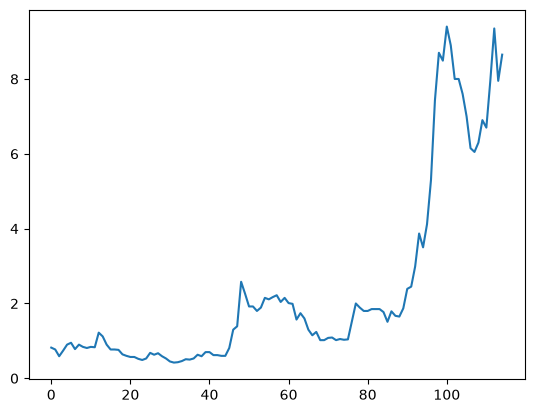

In [4]:
plt.plot(livestock_end_month_df['close_price'])
plt.show()

In [5]:
livestock_end_month_df['returns']=livestock_end_month_df['close_price'].pct_change()*100
livestock_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45353,LIVESTOCK,2017-01-31,0.82,0.82,286262,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47174,LIVESTOCK,2017-02-28,0.77,0.77,67372,2026-04-08T02:44:45.006295+00:00,2,1,2017,-6.097561
2,49290,LIVESTOCK,2017-03-31,0.59,0.59,780700,2026-04-08T02:45:42.281198+00:00,3,1,2017,-23.376623
3,51118,LIVESTOCK,2017-04-28,0.74,0.74,3215632,2026-04-08T02:51:55.619599+00:00,4,2,2017,25.423729
4,53040,LIVESTOCK,2017-05-31,0.90,0.90,1718073,2026-04-08T02:52:57.421655+00:00,5,2,2017,21.621622
...,...,...,...,...,...,...,...,...,...,...,...
110,35324,LIVESTOCK,2026-03-31,6.70,6.70,1080267,2026-03-31T15:00:02.085058+00:00,3,1,2026,-2.898551
111,281150,LIVESTOCK,2026-04-30,7.95,7.95,6998476,2026-04-30T15:00:02.170664+00:00,4,2,2026,18.656716
112,284216,LIVESTOCK,2026-05-29,9.35,9.35,1207176,2026-05-29T15:00:02.455558+00:00,5,2,2026,17.610063
113,294144,LIVESTOCK,2026-06-30,7.95,7.95,692735,2026-06-30T15:10:03.08168+00:00,6,2,2026,-14.973262


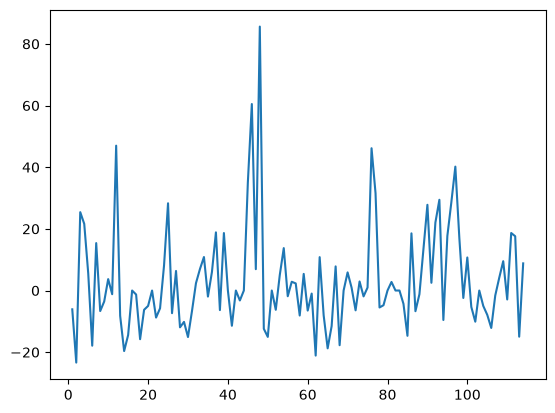

In [6]:
plt.plot(livestock_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(livestock_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-6.418694859818056), np.float64(1.8141119731203993e-08), 1, 112, {'1%': np.float64(-3.4901313156261384), '5%': np.float64(-2.8877122815688776), '10%': np.float64(-2.5807296460459184)}, np.float64(845.2452979816255))
stationary


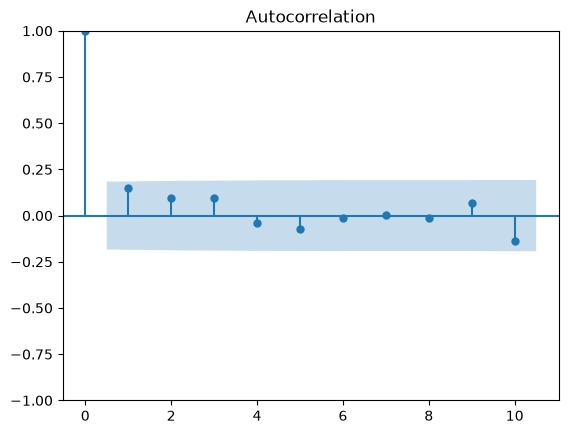

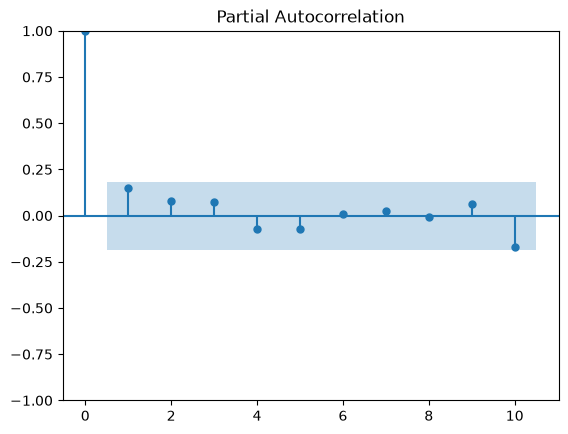

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(livestock_end_month_df['returns'].dropna(), lags=10)
plot_pacf(livestock_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=livestock_end_month_df['close_price'][:-10]
test=livestock_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -46.88957325120986]
[0, 0, 0, 0, 0, 1, -11.683131756521524]
[0, 0, 0, 0, 0, 2, -1.771675594014074]
[0, 0, 0, 0, 1, 0, -1.4148086229652446]
[0, 0, 0, 0, 1, 1, -2.718197606120133]
[0, 0, 0, 0, 1, 2, -3.147315755470353]
[0, 0, 0, 0, 2, 0, -28.30319401695338]
[0, 0, 0, 0, 2, 1, -19.676238336627517]
[0, 0, 0, 0, 2, 2, -17.061973695984687]
[0, 0, 0, 1, 0, 0, -2.5938170182263103]
[0, 0, 0, 1, 0, 1, -2.1088868528045084]
[0, 0, 0, 1, 0, 2, -4.88500057252337]
[0, 0, 0, 1, 1, 0, -2.5581471040397026]
[0, 0, 0, 1, 1, 1, -2.7866947665295947]
[0, 0, 0, 1, 1, 2, -2.547372541003711]
[0, 0, 0, 1, 2, 0, -22.700709683893606]
[0, 0, 0, 1, 2, 1, -18.141545100251335]
[0, 0, 0, 1, 2, 2, -18.25604177988777]
[0, 0, 0, 2, 0, 0, -2.369467309001096]
[0, 0, 0, 2, 0, 1, -2.1134243572761884]
[0, 0, 0, 2, 0, 2, -3.319486460847479]
[0, 0, 0, 2, 1, 0, -2.6570137131609846]
[0, 0, 0, 2, 1, 1, -2.635850760668667]
[0, 0, 0, 2, 1, 2, -6.802738926158908]
[0, 0, 0, 2, 2, 0, -21.620981605935523]
[0, 0, 0, 2, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
627,2,1,2,0,2,0,-72.760062
222,0,2,2,0,2,0,-66.998636
87,0,1,0,0,2,0,-65.208500
438,1,2,1,0,2,0,-64.806898
708,2,2,2,0,2,0,-64.022214
...,...,...,...,...,...,...,...
500,2,0,0,1,1,2,0.081572
491,2,0,0,0,1,2,0.081888
675,2,2,1,0,0,0,0.113482
508,2,0,0,2,1,1,0.141793


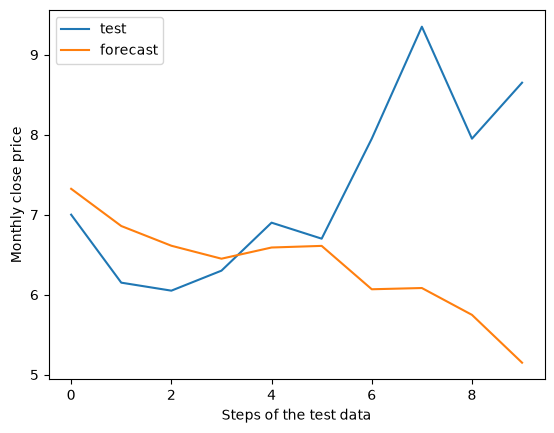

r2_score:  -1.8483113713930437
rmse:  1.7991958963904386
description:  count    115.000000
mean       2.341826
std        2.506891
min        0.420000
25%        0.750000
50%        1.300000
75%        2.160000
max        9.400000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=livestock_end_month_df['close_price'][:-10]
y_test=livestock_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', livestock_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=livestock_end_month_df['returns'].dropna()[:-10]
test=livestock_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.029428411043361358]
[0, 0, 0, 0, 0, 1, -0.017619190497945025]
[0, 0, 0, 0, 0, 2, 0.017584422689088663]
[0, 0, 0, 0, 1, 0, -2.7207195676543425]
[0, 0, 0, 0, 1, 1, -0.36208320908698743]
[0, 0, 0, 0, 1, 2, -0.36231332003735783]
[0, 0, 0, 0, 2, 0, -15.056831271170452]
[0, 0, 0, 0, 2, 1, -3.594268924837837]
[0, 0, 0, 0, 2, 2, -0.9300675658302384]
[0, 0, 0, 1, 0, 0, -0.018953003145506297]
[0, 0, 0, 1, 0, 1, -0.04437682004001697]
[0, 0, 0, 1, 0, 2, -0.047230347763234315]
[0, 0, 0, 1, 1, 0, -0.9430640349949055]
[0, 0, 0, 1, 1, 1, -0.3618972659199886]
[0, 0, 0, 1, 1, 2, -0.6779424386900199]
[0, 0, 0, 1, 2, 0, -6.760642586752318]
[0, 0, 0, 1, 2, 1, -1.9113302233013383]
[0, 0, 0, 1, 2, 2, -0.9367497216626588]
[0, 0, 0, 2, 0, 0, 0.004034184773681337]
[0, 0, 0, 2, 0, 1, -0.04424383185381364]
[0, 0, 0, 2, 0, 2, -0.11801879630943457]
[0, 0, 0, 2, 1, 0, -0.7212411746673069]
[0, 0, 0, 2, 1, 1, -0.41270711636218316]
[0, 0, 0, 2, 1, 2, -0.47402183418451904]
[0, 0, 0, 2, 2, 0, -4.559

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
177,0,2,0,1,2,0,-904.830238
168,0,2,0,0,2,0,-652.115135
169,0,2,0,0,2,1,-370.185627
179,0,2,0,1,2,2,-324.176442
178,0,2,0,1,2,1,-242.085778
...,...,...,...,...,...,...,...
415,1,2,0,1,0,1,0.130713
405,1,2,0,0,0,0,0.132233
648,2,2,0,0,0,0,0.135761
414,1,2,0,1,0,0,0.159507


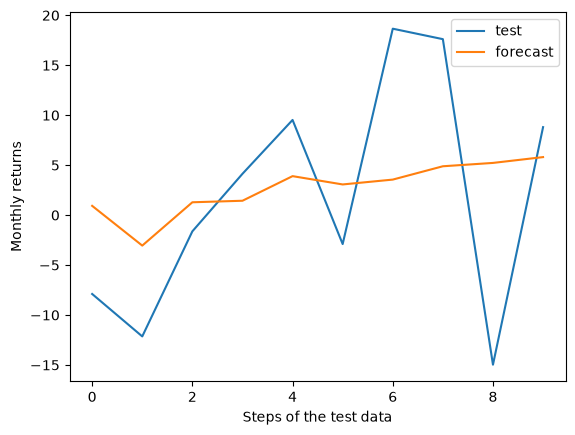

r2_score:  0.16092216388947478
rmse:  10.248201444613247
description:  count    114.000000
mean       3.291593
std       16.944178
min      -23.376623
25%       -6.627907
50%        0.000000
75%        8.644590
max       85.611511
Name: returns, dtype: float64


In [15]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=livestock_end_month_df['returns'].dropna()[:-10]
y_test=livestock_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,0), 
seasonal_order=(0,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', livestock_end_month_df.returns.dropna().describe())

Very horrible. But we will work with it.
